In [1]:
import pandas as pd
import os
import numpy as np
import math
import pytaxonkit
import subprocess
import json

In [12]:
!datasets summary taxonomy taxon "Propionibacterium acnes"

{"reports": [{"query":["Propionibacterium acnes"],"taxonomy":{"children":[1734926,1905725,1734925,686659,679193,553199,1136877,1249618,1292038,1292039,1302640,1302639,1302638,1302637,1182752,1302636,1302635,1182751,1302634,267747,1302244,1302243,1302242,1302241,679195,679194,1271533,1271528,765080,765079,765078,765077,765059,765060,765061,765062,765063,765064,765057,765058,1134454,765086,765083,765082,765081,765093,765088,765087,765121,765120,765071,765076,765075,765074,765110,765114,765113,765084,765092,765091,765119,765067,765066,765102,765101,765100,765095,765094,765068,765073,765072,1226748,765085,765122,765108,765107,765106,765104,765103,765112,765111,765090,765089,765065,765070,765069,765118,765099,765098,765097,765096,765117,765116,765115,765105,1276648,1276649,1122995,1234380,1136879,1350464,1308734,883088,1031709,1350463,909952,1249620,1249619,1249617,1249616,1182750,1182749],"classification":{"class":{"id":1760,"name":"Actinomycetes"},"domain":{"id":2,"name":"Bacteria"},"fami

In [3]:
def get_virus_metadata(virus_names):
    virus_metadata = {}

    n = len(virus_names)
    step = 100
    for i in range(0, n, step):
        print(i)
    #for virus_name in virus_names:
        try:
            virus_names_list = ",".join(virus_names[i : i + step])
            output = subprocess.run(["datasets", "summary", "taxonomy", "taxon", virus_names_list], capture_output=True)
            #tax_json = json.loads(output.stdout)["reports"][0]["taxonomy"]["classification"]
            reports = json.loads(output.stdout)["reports"]
            report_count = int(tax_json["total_count"])
            for report in reports:
                virus_name = report["query"][0]
                tax_json = report["taxonomy"]["classification"]
                metadata = {}
                if "species" in tax_json:
                    metadata["species_tax_name"] = tax_json["species"]["name"]
                    metadata["species_tax_id"] = tax_json["species"]["id"]
    
                if "genus" in tax_json:
                    metadata["genus_tax_name"] = tax_json["genus"]["name"]
                    metadata["genus_tax_id"] = tax_json["genus"]["id"]
    
                if "family" in tax_json:
                    metadata["family_tax_name"] = tax_json["family"]["name"]
                    metadata["family_tax_id"] = tax_json["family"]["id"]
                virus_metadata[virus_name] = metadata
        except:
            pass
    return virus_metadata

## Virion

In [4]:
dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "input/data/virion/20260326/virion_filtered_20260327.csv")
df = pd.read_csv(dataset_csv_filepath,  encoding="latin-1", low_memory=False)
print(f"Dataset size: {df.shape}")
df.columns

Dataset size: (777873, 36)


Index(['Host', 'Virus', 'HostTaxID', 'VirusTaxID', 'HostNCBIResolved',
       'VirusNCBIResolved', 'ICTVRatified', 'HostGenus', 'HostFamily',
       'HostOrder', 'HostClass', 'HostOriginal', 'VirusGenus', 'VirusFamily',
       'VirusOrder', 'VirusClass', 'VirusOriginal', 'HostFlagID',
       'DetectionMethod', 'DetectionOriginal', 'Database', 'DatabaseVersion',
       'PublicationYear', 'ReferenceText', 'PMID', 'ReleaseYear',
       'ReleaseMonth', 'ReleaseDay', 'CollectionYear', 'CollectionMonth',
       'CollectionDay', 'AssocID', 'DatabaseDOI', 'Release_Date',
       'Collection_Date', 'NCBIAccession'],
      dtype='object')

In [5]:
df.iloc[0, :]

Host                                                               NaN
Virus                                                              NaN
HostTaxID                                                      10040.0
VirusTaxID                                                         NaN
HostNCBIResolved                                                  True
VirusNCBIResolved                                                  NaN
ICTVRatified                                                     False
HostGenus                                                   peromyscus
HostFamily                                                  cricetidae
HostOrder                                                     rodentia
HostClass                                                     mammalia
HostOriginal                                                Peromyscus
VirusGenus                                                         NaN
VirusFamily                                                        NaN
VirusO

In [6]:
viruses = df["VirusOriginal"].unique()
print(len(viruses))

14873


In [ ]:
virus_metadata = get_virus_metadata(viruses)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600


In [ ]:
df.rename(columns={"HostTaxID": "host_tax_id",
                  "VirusTaxID": "virus_tax_id",
                  "NCBIAccession": "genbank_accession_id"}, inplace=True)

In [12]:

df

,Host,Virus,host_tax_id,virus_tax_id,HostNCBIResolved,VirusNCBIResolved,ICTVRatified,HostGenus,HostFamily,HostOrder,...,ReleaseMonth,ReleaseDay,CollectionYear,CollectionMonth,CollectionDay,AssocID,DatabaseDOI,Release_Date,Collection_Date,genbank_accession_id
0,NaN,NaN,10040.0,NaN,True,NaN,False,peromyscus,cricetidae,rodentia,...,11.0,26.0,2006.0,NaN,NaN,NaN,NaN,2011-11-26,2006,JN196141.1
1,NaN,NaN,10040.0,NaN,True,NaN,False,peromyscus,cricetidae,rodentia,...,11.0,26.0,2006.0,NaN,NaN,NaN,NaN,2011-11-26,2006,JN196144.1
2,NaN,NaN,10040.0,NaN,True,NaN,False,peromyscus,cricetidae,rodentia,...,11.0,26.0,2006.0,NaN,NaN,NaN,NaN,2011-11-26,2006,JN196145.1
3,NaN,NaN,10040.0,NaN,True,NaN,False,peromyscus,cricetidae,rodentia,...,11.0,26.0,2006.0,NaN,NaN,NaN,NaN,2011-11-26,2006,JN196139.1
4,NaN,NaN,10040.0,NaN,True,NaN,False,peromyscus,cricetidae,rodentia,...,11.0,26.0,2006.0,NaN,NaN,NaN,NaN,2011-11-26,2006,JN196143.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777868,zygodontomys brevicauda,zygodontomys brevicauda hepacivirus 2,157541.0,2875887.0,True,True,False,zygodontomys,cricetidae,rodentia,...,9.0,19.0,NaN,NaN,NaN,NaN,NaN,2021-09-19,NaN,MT732112.1
777869,zygodontomys brevicauda,zygodontomys brevicauda polyomavirus,157541.0,2875888.0,True,True,False,zygodontomys,cricetidae,rodentia,...,9.0,19.0,NaN,NaN,NaN,NaN,NaN,2021-09-19,NaN,MT732104.1
777870,zygodontomys cherriei,orthohantavirus sp. 'necocliense',218840.0,3052488.0,True,True,False,zygodontomys,cricetidae,rodentia,...,2.0,15.0,2008.0,NaN,NaN,NaN,NaN,2012-02-15,2008,"JN717148.1, JN717149.1"
777871,zygodontomys cherriei,orthohantavirus sp. 'necocliense',218840.0,3052488.0,True,True,False,zygodontomys,cricetidae,rodentia,...,8.0,29.0,2008.0,3.0,16.0,NaN,NaN,2015-08-29,2008-03-16,KM196124.1


In [13]:
df.dtypes

Host                     object
Virus                    object
host_tax_id             float64
virus_tax_id            float64
HostNCBIResolved           bool
VirusNCBIResolved        object
ICTVRatified               bool
HostGenus                object
HostFamily               object
HostOrder                object
HostClass                object
HostOriginal             object
VirusGenus               object
VirusFamily              object
VirusOrder               object
VirusClass               object
VirusOriginal            object
HostFlagID                 bool
DetectionMethod          object
DetectionOriginal        object
Database                 object
DatabaseVersion          object
PublicationYear         float64
ReferenceText           float64
PMID                    float64
ReleaseYear             float64
ReleaseMonth            float64
ReleaseDay              float64
CollectionYear          float64
CollectionMonth         float64
CollectionDay           float64
AssocID 

In [23]:
virion_df = df[["host_tax_id", "virus_tax_id", "genbank_accession_id"]]
virion_df["dataset_source"] = "virion"
# hack to convert virs_tax_id to int because of bugs in pandas method
#virion_df.fillna(value={"virus_tax_id": -1}, inplace=True)
virion_df["virus_tax_id"] = virion_df["virus_tax_id"].astype("Int64")
#virion_df["virus_tax_id"] = pd.to_numeric(virion_df["virus_tax_id"], downcast="integer", errors="coerce")
# virion_df.replace({"virus_tax_id": -1}, np.nan, inplace=True)

virion_df["host_tax_id"] = pd.to_numeric(virion_df["host_tax_id"], downcast="integer", errors="coerce")

virion_df["genbank_accession_id"] = virion_df["genbank_accession_id"].apply(lambda x: x.split(".")[0])
print(f"Dataset size: {virion_df.shape}")
virion_df

/tmp/ipykernel_2027701/3375934482.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  virion_df["dataset_source"] = "virion"
/tmp/ipykernel_2027701/3375934482.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  virion_df["virus_tax_id"] = virion_df["virus_tax_id"].astype("Int64")
/tmp/ipykernel_2027701/3375934482.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

Dataset size: (777873, 4)


/tmp/ipykernel_2027701/3375934482.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  virion_df["genbank_accession_id"] = virion_df["genbank_accession_id"].apply(lambda x: x.split(".")[0])


,host_tax_id,virus_tax_id,genbank_accession_id,dataset_source
0,10040,<NA>,JN196141,virion
1,10040,<NA>,JN196144,virion
2,10040,<NA>,JN196145,virion
3,10040,<NA>,JN196139,virion
4,10040,<NA>,JN196143,virion
...,...,...,...,...
777868,157541,2875887,MT732112,virion
777869,157541,2875888,MT732104,virion
777870,218840,3052488,JN717148,virion
777871,218840,3052488,KM196124,virion


## VMR

In [24]:
dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "input/data/vmr/VMR_MSL41.v1.20260320.csv")
df = pd.read_csv(dataset_csv_filepath, low_memory=False)
print(f"Dataset size: {df.shape}")
df.columns

Dataset size: (19271, 34)


Index(['Isolate ID', 'Species Sort', 'Isolate Sort', 'Realm', 'Subrealm',
       'Kingdom', 'Subkingdom', 'Phylum', 'Subphylum', 'Class', 'Subclass',
       'Order', 'Suborder', 'Family', 'Subfamily', 'Genus', 'Subgenus',
       'Species', 'ICTV_ID', 'Exemplar or additional isolate', 'Virus name(s)',
       'Virus name abbreviation(s)', 'Virus isolate designation',
       'Virus GENBANK accession', 'Genome coverage', 'Genome', 'Host source',
       'Accessions Link', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30',
       'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33'],
      dtype='object')

In [25]:
df

,Isolate ID,Species Sort,Isolate Sort,Realm,Subrealm,Kingdom,Subkingdom,Phylum,Subphylum,Class,...,Genome coverage,Genome,Host source,Accessions Link,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,VMR1028127,1,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,Complete genome,dsDNA,archaea,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
1,VMR1000002,2,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,Complete genome,dsDNA,archaea,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
2,VMR1000001,3,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,Coding-complete genome,dsDNA,archaea,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
3,VMR1000003,4,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,Complete genome,dsDNA,archaea,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
4,VMR1000008,5,1,Adnaviria,NaN,Zilligvirae,NaN,Taleaviricota,NaN,Tokiviricetes,...,Complete genome,dsDNA,archaea,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19266,VMR1006179,17550,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Complete genome,ssDNA,plants,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
19267,VMR1006180,17551,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Complete genome,ssDNA,plants,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
19268,VMR1030577,17552,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Complete genome,dsDNA,archaea,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN
19269,VMR1030664,17553,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Complete genome,dsDNA,archaea,NCBI Nucleotide,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df["Exemplar or additional isolate"].value_counts()

E    17554
A     1717
Name: Exemplar or additional isolate, dtype: int64

In [57]:
!export TAXONKIT_DB="/home/blessyantony/dev/git/taxonkit"

In [58]:
virus_species = list(df["Species"].unique())

with open(os.path.join(os.getcwd(), "..", "..", "..","..", "input/data/virion/20260326/virion_filtered_20260327_species_names.csv"), "w+") as f:
    f.write("\n".join(virus_species))

In [59]:
virus_species_name_id_df = pytaxonkit.name2taxid(virus_species)

In [60]:
virus_species_name_id_df[virus_species_name_id_df["TaxID"].isna()]

,Name,TaxID,Rank
29,Yumkaaxvirus juandefucaense,<NA>,<NA>
186,Pradovirus pagan,<NA>,<NA>
269,Friunavirus 02KEN01,<NA>,<NA>
270,Friunavirus 1137KEN02,<NA>,<NA>
271,Friunavirus 1137KEN03,<NA>,<NA>
...,...,...,...
17532,Betasatellite trigonellae,<NA>,<NA>
17538,Deltasatellite brassicae,<NA>,<NA>
17551,Ispindelvirus danakilense,<NA>,<NA>
17552,Kodayamazakivirus kyodaii,<NA>,<NA>


/home/blessyantony/dev/tools/.taxonkit


In [53]:
virus_species_df = pd.read_table(os.path.join(os.getcwd(), "..", "..", "..","..", "input/data/virion/20260326/virus_species_taxids.txt"), sep="|", skipinitialspace=True, header=0)
virus_species_df

,code\t,\tname\t,\tpreferred name\t,\ttaxid
0,1,\tWargodvirus xiongnu\t,\t \t,\t3424310
1,1,\tAlphalipothrixvirus beppuense\t,\t \t,\t2734584
2,1,\tAlphalipothrixvirus umijigokuense\t,\t \t,\t2734583
3,1,\tBetalipothrixvirus acidiani\t,\t \t,\t346881
4,1,\tBetalipothrixvirus hveragerdiense\t,\t \t,\t3427236
...,...,...,...,...
17549,1,\tDeltasatellite solaniflavusprimi\t,\t \t,\t3428225
17550,1,\tDeltasatellite solaniflavussecundi\t,\t \t,\t3428226
17551,1,\tIspindelvirus danakilense\t,\t \t,\t3703011
17552,1,\tKodayamazakivirus kyodaii\t,\t \t,\t3703085


In [11]:
df.rename(columns={"ICTV_ID": "virus_ictv_id",
                  "Virus GENBANK accession": "genbank_accession_id"}, inplace=True)

In [12]:
vmr_df = df[["virus_ictv_id", "genbank_accession_id"]]
vmr_df["dataset_source"] = "vmr"
print(f"Dataset size: {vmr_df.shape}")
vmr_df

Dataset size: (19271, 3)


/tmp/ipykernel_1951231/3112884574.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vmr_df["dataset_source"] = "vmr"


,virus_ictv_id,genbank_accession_id,dataset_source
0,ICTV202420188,PP467602,vmr
1,ICTV201908643,MH447526,vmr
2,ICTV201908644,MK064563,vmr
3,ICTV20094000,AM087120,vmr
4,ICTV20041365,AF440571,vmr
...,...,...,...
19266,ICTV20165500,JN819495,vmr
19267,ICTV20165501,KU232893,vmr
19268,ICTV202522171,PQ827552,vmr
19269,ICTV202522258,HE580238,vmr


## NCBI Virus

In [5]:
dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "input/data/ncbi_virus/viral_genomes_complete_refseq_20260429.csv")
df = pd.read_csv(dataset_csv_filepath, low_memory=False)
print(f"Dataset size: {df.shape}")
df.columns

Dataset size: (19291, 18)


Index(['Accession', 'SRA_Accession', 'Organism_Name', 'Species', 'Genus',
       'Family', 'Genotype', 'Isolate', 'Segment', 'Length',
       'Nuc_Completeness', 'Geo_Location', 'Host', 'Tissue_Specimen_Source',
       'Submitters', 'Collection_Date', 'Release_Date', 'Molecule_type'],
      dtype='object')

In [6]:
df

,Accession,SRA_Accession,Organism_Name,Species,Genus,Family,Genotype,Isolate,Segment,Length,Nuc_Completeness,Geo_Location,Host,Tissue_Specimen_Source,Submitters,Collection_Date,Release_Date,Molecule_type
0,NC_115699.1,NaN,Macrophomina phaseolina fusagravirus 1,Fusagravirus jyugo,Fusagravirus,Fusagraviridae,NaN,NaN,NaN,9289,complete,China,Macrophomina phaseolina,NaN,"Wang,J., Xiao,Y., Zhao,H., Ni,Y., Liu,X., Zhao...",2012-08-19,2026-04-21,dsRNA
1,NC_116531.1,NaN,Picoa juniperi mycovirus 1,Fusagravirus jyuroku,Fusagravirus,Fusagraviridae,NaN,ANK_VIR-89,NaN,10787,complete,Turkey,Picoa juniperi,NaN,"Sahin,E., Keskin,E., Akata,I.",2020-06-10,2026-04-21,dsRNA
2,NC_116560.1,NaN,Achimota pararubulavirus 3,Pararubulavirus eidoli,Pararubulavirus,Paramyxoviridae,NaN,U72,NaN,15600,complete,Ghana,Eidolon helvum,NaN,"Baker,K.S., Tachedjian,M., Barr,J., Marsh,G.A....",2010-11-20,2026-04-21,ssRNA(-)
3,NC_116689.1,NaN,Caloscypha fulgens fusagravirus 1,Fusagravirus jyuhachi,Fusagravirus,Fusagraviridae,NaN,ANK VIR-100,NaN,9548,complete,Turkey,Caloscypha fulgens,NaN,"Sahin,E., Akata,I., Keskin,E.",2020-04-28,2026-04-21,dsRNA
4,NC_116858.1,NaN,Wufeng Niviventer fulvescens morbillivirus 1,Paramorbillivirus niviventris,Paramorbillivirus,Paramyxoviridae,NaN,WFS_zhenmao,NaN,15145,complete,China,Niviventer fulvescens,NaN,"Tan,Z., Nie,F.-Y., Zhang,Y.-Z.",2016,2026-04-21,ssRNA(-)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19286,NC_002023.1,NaN,Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Alphainfluenzavirus influenzae,Alphainfluenzavirus,Orthomyxoviridae,H1N1,NaN,1,2341,complete,Puerto Rico,NaN,NaN,"Fields,S., Winter,G.",1934,1982-11-03,ssRNA(-)
19287,NC_002058.3,NaN,Enterovirus C,Enterovirus coxsackiepol,Enterovirus,Picornaviridae,NaN,NaN,Unknown,7440,complete,NaN,NaN,NaN,"Kafasla,P., Morgner,N., Robinson,C.V., Jackson...",NaN,1982-11-03,ssRNA(+)
19288,NC_002016.1,NaN,Influenza A virus (A/Puerto Rico/8/1934(H1N1)),Alphainfluenzavirus influenzae,Alphainfluenzavirus,Orthomyxoviridae,H1N1,NaN,7,1027,complete,Puerto Rico,NaN,NaN,"Winter,G., Fields,S.",1934,1982-06-09,ssRNA(-)
19289,NC_002030.1,NaN,Potato spindle tuber viroid,Pospiviroid fusituberis,Pospiviroid,Pospiviroidae,NaN,NaN,Unknown,359,complete,NaN,NaN,NaN,"Diener,T.O., Gross,H.J., Domdey,H., Lossow,C.,...",NaN,1982-06-09,ssRNA


In [9]:
list(df["Host"].value_counts().index)

['Mycolicibacterium smegmatis MC2 155',
 'Escherichia coli',
 'activated sludge metagenome',
 'Homo sapiens',
 'Gordonia terrae',
 'Klebsiella pneumoniae',
 'Solanum lycopersicum',
 'Pseudomonas aeruginosa',
 'Lactococcus lactis',
 'Salmonella enterica',
 'Streptococcus thermophilus',
 'Staphylococcus aureus',
 'Glypta fumiferanae',
 'Plasmopara viticola',
 'Gallus gallus',
 'Culicidae',
 'Sus scrofa',
 'Odonata',
 'Bos taurus',
 '[Arthrobacter] sp. ATCC 21022',
 'Microbacterium foliorum',
 'Escherichia',
 'Cutibacterium acnes',
 'Vitis vinifera',
 'Diptera',
 'Mycobacterium',
 'Arthropoda',
 'Mycolicibacterium smegmatis',
 'Hyposoter fugitivus',
 'Arthrobacter globiformis',
 'Astacoidea',
 'Hexapoda',
 'Octopus',
 'Enterococcus faecalis',
 'Erwinia amylovora',
 'Culex',
 'Acinetobacter baumannii',
 'Crustacea',
 'Sclerotinia sclerotiorum',
 'Zea mays',
 'Botrytis cinerea',
 'Pseudomonas',
 'Bacillus cereus',
 'Escherichia coli O157:H7',
 'Myriapoda',
 'Vicia faba',
 'Lathyrus oleraceu

In [15]:
df.rename(columns={"Species": "virus_species_name",
                  "Accession": "refseq_accession_id"}, inplace=True)

In [16]:
ncbi_virus_df = df[["virus_species_name", "refseq_accession_id"]]
ncbi_virus_df["dataset_source"] = "ncbi_virus"
print(f"Dataset size: {ncbi_virus_df.shape}")
ncbi_virus_df

Dataset size: (19291, 3)


/tmp/ipykernel_1951231/279565083.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ncbi_virus_df["dataset_source"] = "ncbi_virus"


,virus_species_name,refseq_accession_id,dataset_source
0,Fusagravirus jyugo,NC_115699.1,ncbi_virus
1,Fusagravirus jyuroku,NC_116531.1,ncbi_virus
2,Pararubulavirus eidoli,NC_116560.1,ncbi_virus
3,Fusagravirus jyuhachi,NC_116689.1,ncbi_virus
4,Paramorbillivirus niviventris,NC_116858.1,ncbi_virus
...,...,...,...
19286,Alphainfluenzavirus influenzae,NC_002023.1,ncbi_virus
19287,Enterovirus coxsackiepol,NC_002058.3,ncbi_virus
19288,Alphainfluenzavirus influenzae,NC_002016.1,ncbi_virus
19289,Pospiviroid fusituberis,NC_002030.1,ncbi_virus


## BVBRC

In [7]:
dataset_csv_filepath = os.path.join(os.getcwd(), "..", "..", "..","..", "input/data/bvbrc/BVBRC_reference_genome_20260429.csv")
df = pd.read_csv(dataset_csv_filepath, low_memory=False)
print(f"Dataset size: {df.shape}")
df.columns

Dataset size: (15731, 90)


Index(['Genome ID', 'Genome Name', 'Other Names', 'NCBI Taxon ID',
       'Taxon Lineage IDs', 'Taxon Lineage Names', 'Superkingdom', 'Kingdom',
       'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species',
       'Genome Status', 'Strain', 'Serovar', 'Biovar', 'Pathovar', 'MLST',
       'Segment', 'Subtype', 'H_type', 'N_type', 'H1 Clade Global',
       'H1 Clade US', 'H5 Clade', 'pH1N1-like', 'Lineage', 'Clade', 'Subclade',
       'Other Typing', 'Culture Collection', 'Type Strain', 'Reference',
       'Genome Quality', 'Completion Date', 'Publication', 'Authors',
       'BioProject Accession', 'BioSample Accession', 'Assembly Accession',
       'SRA Accession', 'GenBank Accessions', 'Sequencing Center',
       'Sequencing Status', 'Sequencing Platform', 'Sequencing Depth',
       'Assembly Method', 'Chromosome', 'Plasmids', 'Contigs', 'Size',
       'GC Content', 'Contig L50', 'Contig N50', 'TRNA', 'RRNA', 'Mat Peptide',
       'CDS', 'Coarse Consistency', 'Fine Consistency', 'Ch

In [8]:
df

,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Host Age,Host Health,Host Group,Lab Host,Passage,Other Clinical,Additional Metadata,Comments,Date Inserted,Date Modified
0,1000373.10,Rosellinia necatrix quadrivirus 1 W1118,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T11:05:04.123Z,2025-12-06T11:05:04.123Z
1,1000373.40,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.037Z,2025-12-06T08:01:47.037Z
2,1000373.50,Rosellinia necatrix quadrivirus 1 W1075,NaN,1000373,10239;2559587;2732396;2732405;2732458;2732540;...,Viruses;Riboviria;Orthornavirae;Duplornavirico...,Viruses,Orthornavirae,Duplornaviricota,Chrymotiviricetes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-06T08:01:47.164Z,2025-12-06T08:01:47.164Z
3,1000411.30,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Nonhuman Mammal,NaN,NaN,NaN,NaN,NaN,2021-01-23T22:04:18.329Z,2021-01-23T22:04:18.329Z
4,1000411.40,Jacunda virus,NaN,1000411,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Nonhuman Mammal,NaN,NaN,NaN,NaN,NaN,2021-01-23T22:06:18.856Z,2021-01-23T22:06:18.856Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15726,999729.23,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:40:21.986Z,2022-03-12T21:40:21.986Z
15727,999729.24,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:34:20.054Z,2022-03-12T21:34:20.054Z
15728,999729.25,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-03-12T21:49:25.104Z,2022-03-12T21:49:25.104Z
15729,999729.35,Leanyer virus AusN16701,NaN,999729,10239;2559587;2732396;2497569;2497571;3151693;...,Viruses;Riboviria;Orthornavirae;Negarnaviricot...,Viruses,Orthornavirae,Negarnaviricota,Bunyaviricetes,...,NaN,NaN,Insect,NaN,NaN,NaN,NaN,NaN,2022-05-01T01:51:20.496Z,2022-05-01T01:51:20.496Z


In [10]:
print(df["Host Name"].nunique())
print(df["Host Common Name"].nunique())

3771
369


In [15]:
print(sum(df["Host Name"].isna()))
print(sum(df["Host Common Name"].isna()))
print(sum(df["Host Name"].isna() | df["Host Common Name"].isna() ))

4349
10393
10427


In [19]:
df.rename(columns={"NCBI Taxon ID": "virus_tax_id",
                  "GenBank Accessions": "genbank_accession_id"}, inplace=True)

In [20]:
bvbrc_df = df[["virus_tax_id", "genbank_accession_id"]]
bvbrc_df["dataset_source"] = "bvbrc"
print(f"Dataset size: {bvbrc_df.shape}")
bvbrc_df

Dataset size: (15731, 3)


/tmp/ipykernel_1951231/1119808361.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bvbrc_df["dataset_source"] = "bvbrc"


,virus_tax_id,genbank_accession_id,dataset_source
0,1000373,AB744679,bvbrc
1,1000373,AB620062,bvbrc
2,1000373,AB620063,bvbrc
3,1000411,HM466934,bvbrc
4,1000411,HM466935,bvbrc
...,...,...,...
15726,999729,HM627176,bvbrc
15727,999729,HM627177,bvbrc
15728,999729,HM627178,bvbrc
15729,999729,NC_043563,bvbrc


In [21]:
virion_genbank_ids = virion_df["genbank_accession_id"].unique()
len(virion_genbank_ids)

777873

In [22]:
vmr_genbank_ids = vmr_df["genbank_accession_id"].unique()
len(vmr_genbank_ids)

19131

In [23]:
ncbi_virus_refseq_ids = ncbi_virus_df["refseq_accession_id"].unique()
len(ncbi_virus_refseq_ids)

19291

In [24]:
bvbrc_genbank_ids = bvbrc_df["genbank_accession_id"].unique()
len(bvbrc_genbank_ids)

15689

In [25]:
!pip install matplotlib-venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


# Virion vs. VMR vs. BVBRC

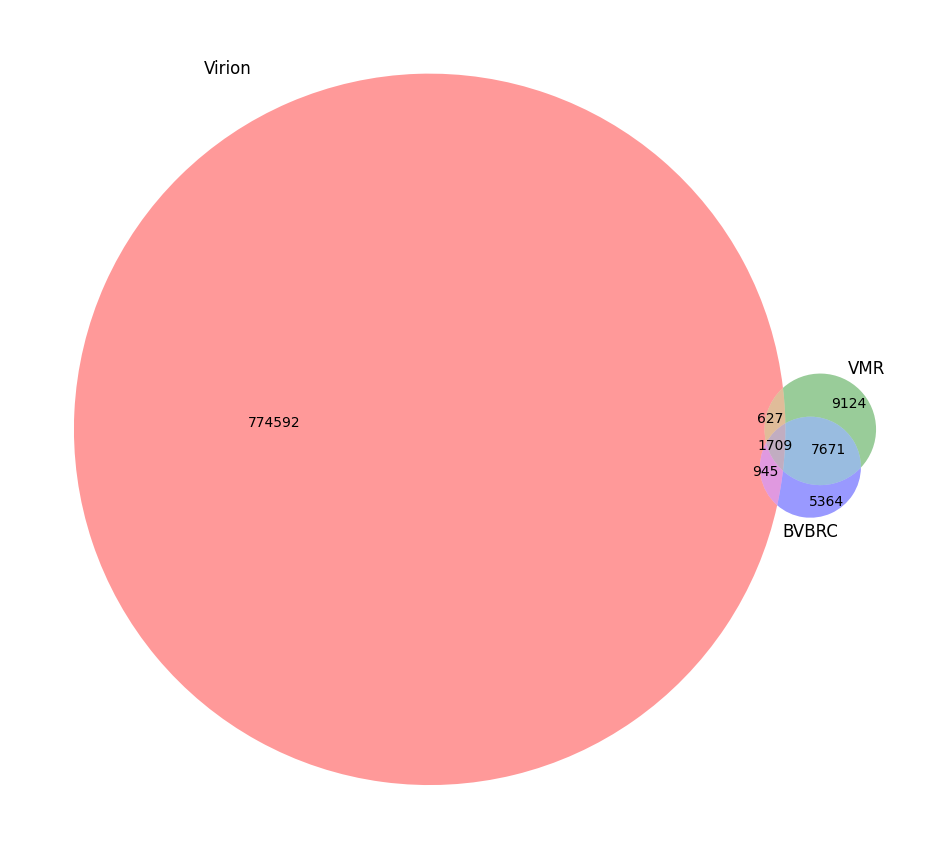

In [26]:
fig, axs = plt.subplots(1, 1, figsize=(12, 12), sharex=False, sharey=True)
x = venn3([set(virion_genbank_ids), set(vmr_genbank_ids), set(bvbrc_genbank_ids)], ("Virion", "VMR", "BVBRC"))
print(x)
# print(len(set(virion_ncbi_ids).intersection(set(ncbi_virus_ncbi_ids))))
# print(len(set(virion_ncbi_ids).union(set(ncbi_virus_ncbi_ids))))

# VMR vs. BVBRC Virus

9380
25440


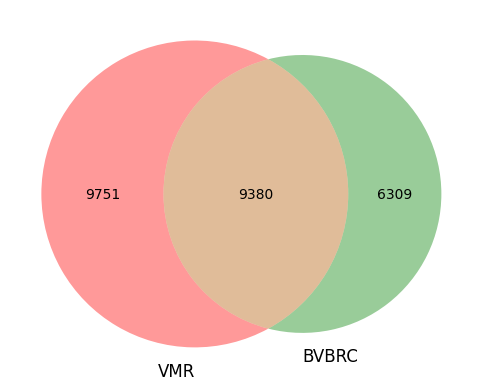

In [27]:
venn2([set(vmr_genbank_ids), set(bvbrc_genbank_ids)], ("VMR", "BVBRC"))
print(len(set(vmr_genbank_ids).intersection(set(bvbrc_genbank_ids))))
print(len(set(vmr_genbank_ids).union(set(bvbrc_genbank_ids))))